# Asset Management Game 🎮📈

A mini stock market game where you must manage a portfolio of 2 stocks to maximize profit.

## Game Rules
- **Initial Capital**: 100,000 EGP
- **Portfolio Constraint**: Must always hold at most 2 stocks at a time
- **Game Period**: July 6 - August 4, 2023
- **Objective**: Maximize portfolio value
- **Available Stocks**: 8 stocks from Egyptian Exchange (EGX)

This notebook builds three strategies and compares them on **final portfolio value**:
1. A simple rule-based strategy (buy the worst recent performers)
2. Buy & Hold
3. An equal-weight **Benchmark** (all 8 stocks)
4. A **Reinforcement Learning (DQN) agent** trained to beat the benchmark


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Game configuration
STOCKS = ['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB']
INITIAL_CAPITAL = 100000
GAME_START = '2023-07-06'
GAME_END = '2023-08-04'
DATA_PATH = './data/egx/'

# Load stock data
stock_data = {}
for stock in STOCKS:
    df = pd.read_csv(f'{DATA_PATH}{stock}.csv')
    df['date'] = pd.to_datetime(df['date'])
    df = df[(df['date'] >= GAME_START) & (df['date'] <= GAME_END)].reset_index(drop=True)
    stock_data[stock] = df

print("✅ Stock data loaded successfully!")
print(f"\n📊 Available stocks: {', '.join(STOCKS)}")
print(f"📅 Game period: {GAME_START} to {GAME_END}")
print(f"💰 Initial capital: {INITIAL_CAPITAL:,.0f} EGP")

# Check data availability
for stock in STOCKS:
    print(f"  {stock}: {len(stock_data[stock])} trading days")


✅ Stock data loaded successfully!

📊 Available stocks: ABUK, ADIB, ALCN, AMOC, ARCC, BTFH, CCAP, CIEB
📅 Game period: 2023-07-06 to 2023-08-04
💰 Initial capital: 100,000 EGP
  ABUK: 19 trading days
  ADIB: 19 trading days
  ALCN: 19 trading days
  AMOC: 19 trading days
  ARCC: 19 trading days
  BTFH: 19 trading days
  CCAP: 19 trading days
  CIEB: 19 trading days


## Price Overview

Let's see the price movements for each stock during the game period:


In [3]:
# Display price statistics
print("\n" + "="*70)
print("STOCK PRICE STATISTICS (July 6 - Aug 4, 2023)")
print("="*70)
stats_data = []
for stock in STOCKS:
    df = stock_data[stock]
    if len(df) > 0:
        start_price = df['close'].iloc[0]
        end_price = df['close'].iloc[-1]
        change = ((end_price - start_price) / start_price) * 100
        max_price = df['high'].max()
        min_price = df['low'].min()
        avg_price = df['close'].mean()
        stats_data.append({
            'Stock': stock,
            'Start': f"{start_price:.2f}",
            'End': f"{end_price:.2f}",
            'Change %': f"{change:.2f}%",
            'High': f"{max_price:.2f}",
            'Low': f"{min_price:.2f}",
            'Avg': f"{avg_price:.2f}"
        })

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))



STOCK PRICE STATISTICS (July 6 - Aug 4, 2023)
Stock Start   End Change %  High   Low   Avg
 ABUK 44.55 46.94    5.36% 49.15 43.11 46.80
 ADIB 19.83 20.01    0.92% 20.83 18.42 19.32
 ALCN 21.89 24.92   13.84% 25.36 20.56 22.94
 AMOC  8.00  8.08    1.00%  9.00  7.60  8.35
 ARCC  7.88  7.00  -11.17%  8.28  6.96  7.56
 BTFH  4.18  3.57  -14.59%  4.65  2.38  3.70
 CCAP  2.92  2.28  -21.92%  2.99  2.24  2.45
 CIEB 13.85 13.76   -0.65% 14.38 12.81 13.64


## 🎮 Game Simulation - Interactive Trading

Let's play! You'll manage a portfolio of 2 stocks over the game period.


In [4]:
class AssetManagementGame:
    def __init__(self, stocks, stock_data, initial_capital, game_start, game_end):
        self.stocks = stocks
        self.stock_data = stock_data
        self.initial_capital = initial_capital
        self.current_cash = initial_capital
        self.portfolio = {}  # {stock: shares}
        self.trade_history = []
        self.portfolio_history = []
        self.game_start = game_start
        self.game_end = game_end

        # Get all trading dates
        all_dates = set()
        for stock in stocks:
            all_dates.update(stock_data[stock]['date'].dt.strftime('%Y-%m-%d').tolist())
        self.trading_dates = sorted(list(all_dates))
        self.current_date_idx = 0

    def get_current_date(self):
        if self.current_date_idx < len(self.trading_dates):
            return self.trading_dates[self.current_date_idx]
        return None

    def get_stock_price(self, stock, date):
        """Get closing price for a stock on a given date"""
        df = self.stock_data[stock]
        try:
            price = df[df['date'] == pd.to_datetime(date)]['close'].values
            return price[0] if len(price) > 0 else None
        except:
            return None

    def buy_stock(self, stock, shares):
        """Buy shares of a stock"""
        if shares <= 0:
            return False, "Invalid share amount"

        price = self.get_stock_price(stock, self.get_current_date())
        if price is None:
            return False, "Stock not available today"

        total_cost = price * shares
        if total_cost > self.current_cash:
            return False, f"Insufficient funds. Need {total_cost:,.0f}, have {self.current_cash:,.0f}"

        if len(self.portfolio) >= 2 and stock not in self.portfolio:
            return False, "Portfolio already has 2 stocks. Sell one first."

        self.portfolio[stock] = self.portfolio.get(stock, 0) + shares
        self.current_cash -= total_cost
        self.trade_history.append({
            'date': self.get_current_date(),
            'type': 'BUY',
            'stock': stock,
            'shares': shares,
            'price': price,
            'total': total_cost
        })
        return True, f"Bought {shares} shares of {stock} at {price:.2f} EGP"

    def sell_stock(self, stock, shares):
        """Sell shares of a stock"""
        if stock not in self.portfolio or self.portfolio[stock] < shares:
            return False, f"Insufficient {stock} shares"

        price = self.get_stock_price(stock, self.get_current_date())
        if price is None:
            return False, "Stock not available today"

        total_revenue = price * shares
        self.portfolio[stock] -= shares
        if self.portfolio[stock] == 0:
            del self.portfolio[stock]

        self.current_cash += total_revenue
        self.trade_history.append({
            'date': self.get_current_date(),
            'type': 'SELL',
            'stock': stock,
            'shares': shares,
            'price': price,
            'total': total_revenue
        })
        return True, f"Sold {shares} shares of {stock} at {price:.2f} EGP"

    def get_portfolio_value(self):
        """Calculate current portfolio value"""
        value = self.current_cash
        current_date = self.get_current_date()
        for stock, shares in self.portfolio.items():
            price = self.get_stock_price(stock, current_date)
            if price:
                value += price * shares
        return value

    def get_portfolio_status(self):
        """Get current portfolio status"""
        current_date = self.get_current_date()
        status = f"\n📅 Date: {current_date} | 💰 Cash: {self.current_cash:,.2f} EGP\n"
        status += f"Portfolio ({len(self.portfolio)}/2 stocks):\n"

        for stock, shares in self.portfolio.items():
            price = self.get_stock_price(stock, current_date)
            if price:
                value = price * shares
                status += f"  {stock}: {shares} shares @ {price:.2f} EGP = {value:,.2f} EGP\n"

        portfolio_value = sum(self.get_stock_price(s, current_date) * sh
                             for s, sh in self.portfolio.items()
                             if self.get_stock_price(s, current_date))
        total_value = self.get_portfolio_value()

        status += f"\n💼 Portfolio Value: {portfolio_value:,.2f} EGP\n"
        status += f"💳 Total Assets: {total_value:,.2f} EGP\n"
        status += f"📈 Profit/Loss: {total_value - self.initial_capital:,.2f} EGP ({((total_value/self.initial_capital - 1) * 100):.2f}%)\n"

        return status

    def advance_day(self):
        """Move to next trading day"""
        if self.current_date_idx < len(self.trading_dates) - 1:
            self.current_date_idx += 1
            # Record portfolio value
            self.portfolio_history.append({
                'date': self.get_current_date(),
                'value': self.get_portfolio_value(),
                'portfolio': self.portfolio.copy()
            })
            return True
        return False

# Initialize the game
game = AssetManagementGame(STOCKS, stock_data, INITIAL_CAPITAL, GAME_START, GAME_END)
print("🎮 Game initialized!")
print(f"\nTotal trading days: {len(game.trading_dates)}")
print(game.get_portfolio_status())


🎮 Game initialized!

Total trading days: 19

📅 Date: 2023-07-06 | 💰 Cash: 100,000.00 EGP
Portfolio (0/2 stocks):

💼 Portfolio Value: 0.00 EGP
💳 Total Assets: 100,000.00 EGP
📈 Profit/Loss: 0.00 EGP (0.00%)



## Strategy & Execution

Let's implement a trading strategy. You can modify this to try different approaches!


In [5]:
# Strategy 1: Buy low performers (potential for recovery)
print("="*70)
print("STRATEGY: Buy underperforming stocks for recovery potential")
print("="*70)

# Calculate returns to find underperformers
returns = {}
for stock in STOCKS:
    df = stock_data[stock]
    if len(df) > 0:
        start = df['close'].iloc[0]
        end = df['close'].iloc[-1]
        returns[stock] = ((end - start) / start) * 100

# Sort by return
sorted_returns = sorted(returns.items(), key=lambda x: x[1])
print("\nStock Returns (sorted):")
for stock, ret in sorted_returns:
    print(f"  {stock}: {ret:+.2f}%")

# Select the 2 worst performers (potential recovery)
stock_to_buy_1 = sorted_returns[0][0]
stock_to_buy_2 = sorted_returns[1][0]
print(f"\n✅ We'll buy: {stock_to_buy_1} and {stock_to_buy_2}")

# Calculate allocation (equal weight)
price_1 = game.get_stock_price(stock_to_buy_1, game.get_current_date())
price_2 = game.get_stock_price(stock_to_buy_2, game.get_current_date())

shares_1 = int((INITIAL_CAPITAL / 2) / price_1)
shares_2 = int((INITIAL_CAPITAL / 2) / price_2)

print(f"\nInitial purchase:")
print(f"  {stock_to_buy_1}: {shares_1} shares @ {price_1:.2f} EGP = {shares_1 * price_1:,.2f} EGP")
print(f"  {stock_to_buy_2}: {shares_2} shares @ {price_2:.2f} EGP = {shares_2 * price_2:,.2f} EGP")
print(f"  Remaining cash: {INITIAL_CAPITAL - (shares_1 * price_1 + shares_2 * price_2):,.2f} EGP")

# Make initial purchases
success1, msg1 = game.buy_stock(stock_to_buy_1, shares_1)
success2, msg2 = game.buy_stock(stock_to_buy_2, shares_2)

print(f"\n{msg1}")
print(f"{msg2}")
print(game.get_portfolio_status())


STRATEGY: Buy underperforming stocks for recovery potential

Stock Returns (sorted):
  CCAP: -21.92%
  BTFH: -14.59%
  ARCC: -11.17%
  CIEB: -0.65%
  ADIB: +0.92%
  AMOC: +1.00%
  ABUK: +5.36%
  ALCN: +13.84%

✅ We'll buy: CCAP and BTFH

Initial purchase:
  CCAP: 17123 shares @ 2.92 EGP = 49,999.16 EGP
  BTFH: 11961 shares @ 4.18 EGP = 49,996.98 EGP
  Remaining cash: 3.86 EGP

Bought 17123 shares of CCAP at 2.92 EGP
Bought 11961 shares of BTFH at 4.18 EGP

📅 Date: 2023-07-06 | 💰 Cash: 3.86 EGP
Portfolio (2/2 stocks):
  CCAP: 17123 shares @ 2.92 EGP = 49,999.16 EGP
  BTFH: 11961 shares @ 4.18 EGP = 49,996.98 EGP

💼 Portfolio Value: 99,996.14 EGP
💳 Total Assets: 100,000.00 EGP
📈 Profit/Loss: 0.00 EGP (0.00%)



In [6]:
# Simulate the game day by day

print("=" * 70)
print("📅 DAILY PORTFOLIO SIMULATION")
print("=" * 70)

daily_results = []

# Record the initial day
daily_results.append({
    'date': game.get_current_date(),
    'portfolio_value': game.get_portfolio_value(),
    'cash': game.current_cash,
    'total_assets': game.get_portfolio_value(),
    'profit_loss': game.get_portfolio_value() - INITIAL_CAPITAL,
    'return_pct': ((game.get_portfolio_value() / INITIAL_CAPITAL) - 1) * 100
})

# Move through all trading days
while game.advance_day():
    current_value = game.get_portfolio_value()

    daily_results.append({
        'date': game.get_current_date(),
        'portfolio_value': current_value,
        'cash': game.current_cash,
        'total_assets': current_value,
        'profit_loss': current_value - INITIAL_CAPITAL,
        'return_pct': ((current_value / INITIAL_CAPITAL) - 1) * 100
    })

daily_df = pd.DataFrame(daily_results)

print("\nDaily Portfolio Performance:")
print(daily_df.to_string(index=False))

print("\n" + "=" * 70)
print("📊 FINAL RESULTS")
print("=" * 70)

final_value = game.get_portfolio_value()
profit = final_value - INITIAL_CAPITAL
return_pct = (profit / INITIAL_CAPITAL) * 100

print(f"Initial Capital : {INITIAL_CAPITAL:,.2f} EGP")
print(f"Final Value     : {final_value:,.2f} EGP")
print(f"Profit/Loss     : {profit:+,.2f} EGP")
print(f"Return          : {return_pct:+.2f}%")


📅 DAILY PORTFOLIO SIMULATION

Daily Portfolio Performance:
      date  portfolio_value     cash  total_assets   profit_loss  return_pct
2023-07-06    100000.000000 3.860747 100000.000000      0.000000    0.000000
2023-07-09     82024.560423 3.860747  82024.560423 -17975.439577  -17.975440
2023-07-10     92813.362771 3.860747  92813.362771  -7186.637229   -7.186637
2023-07-11     92846.098658 3.860747  92846.098658  -7153.901342   -7.153901
2023-07-12     91783.469671 3.860747  91783.469671  -8216.530329   -8.216530
2023-07-13     90995.310423 3.860747  90995.310423  -9004.689577   -9.004690
2023-07-16     89679.601677 3.860747  89679.601677 -10320.398323  -10.320398
2023-07-17     91832.582476 3.860747  91832.582476  -8167.417524   -8.167418
2023-07-18     92348.781984 3.860747  92348.781984  -7651.218016   -7.651218
2023-07-19     92348.781984 3.860747  92348.781984  -7651.218016   -7.651218
2023-07-24     89116.802214 3.860747  89116.802214 -10883.197786  -10.883198
2023-07-25     85

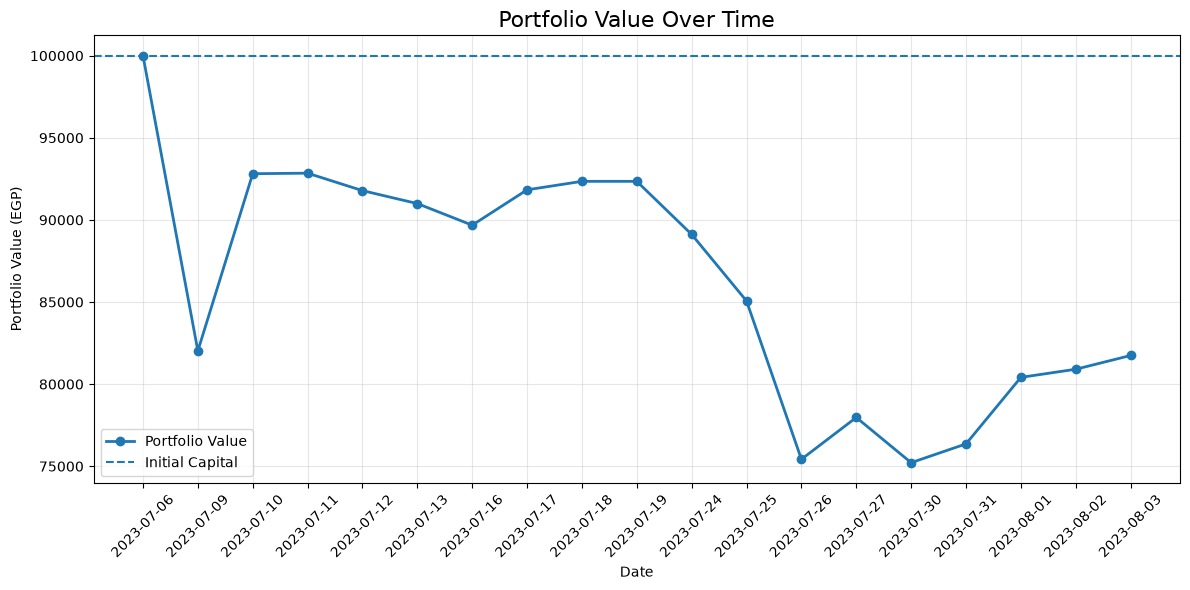

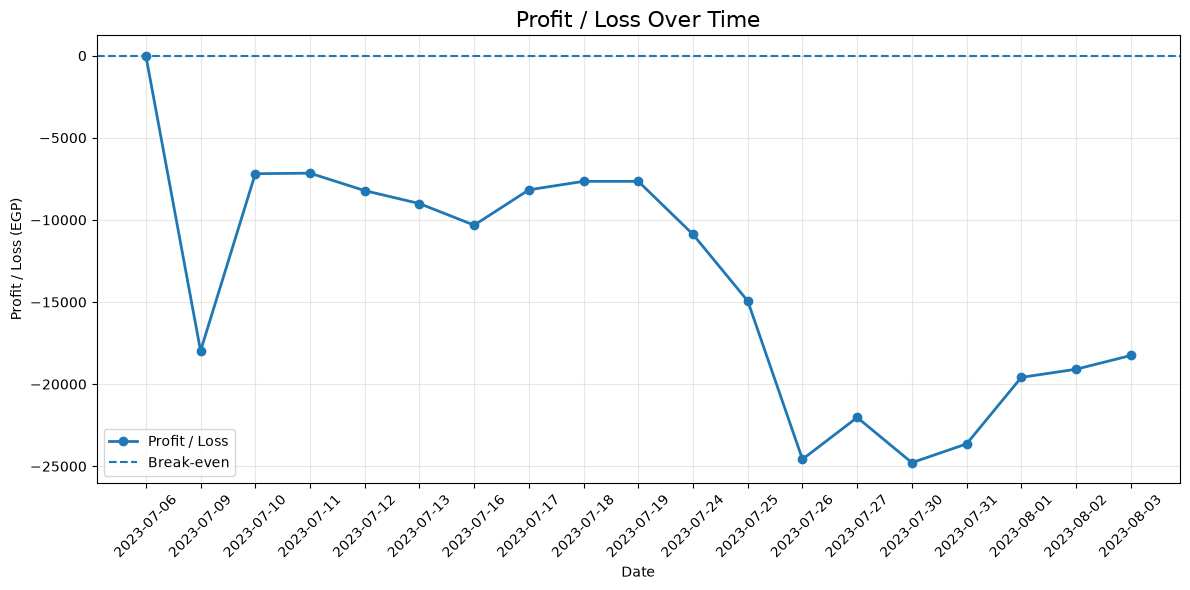

In [7]:
# Plot Portfolio Value and Profit/Loss

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    daily_df['date'],
    daily_df['portfolio_value'],
    marker='o',
    linewidth=2,
    label='Portfolio Value'
)

ax.axhline(
    y=INITIAL_CAPITAL,
    linestyle='--',
    linewidth=1.5,
    label='Initial Capital'
)

ax.set_title('Portfolio Value Over Time', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (EGP)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Profit / Loss Chart
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    daily_df['date'],
    daily_df['profit_loss'],
    marker='o',
    linewidth=2,
    label='Profit / Loss'
)

ax.axhline(
    y=0,
    linestyle='--',
    linewidth=1.5,
    label='Break-even'
)

ax.set_title('Profit / Loss Over Time', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Profit / Loss (EGP)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
# Compare Strategy vs Buy & Hold vs Benchmark

print("=" * 70)
print("📊 STRATEGY vs BUY & HOLD vs BENCHMARK")
print("=" * 70)


# ============================================================
# 1. OUR STRATEGY
# ============================================================

strategy_df = daily_df.copy()

strategy_final_value = strategy_df['portfolio_value'].iloc[-1]
strategy_return = (strategy_final_value / INITIAL_CAPITAL - 1) * 100


# ============================================================
# 2. BUY & HOLD
# ============================================================
# Invest 50% of capital in each of the two selected stocks
# on the first trading day and hold until the end.

buy_hold_initial = INITIAL_CAPITAL
investment_per_stock = INITIAL_CAPITAL / 2

shares_bh_1 = int(investment_per_stock / price_1)
shares_bh_2 = int(investment_per_stock / price_2)

cost_bh_1 = shares_bh_1 * price_1
cost_bh_2 = shares_bh_2 * price_2

remaining_cash_bh = INITIAL_CAPITAL - cost_bh_1 - cost_bh_2

buy_hold_values = []

for date in game.trading_dates:
    p1 = game.get_stock_price(stock_to_buy_1, date)
    p2 = game.get_stock_price(stock_to_buy_2, date)

    if p1 is not None and p2 is not None:
        value = shares_bh_1 * p1 + shares_bh_2 * p2 + remaining_cash_bh
        buy_hold_values.append({'date': date, 'value': value})

buy_hold_df = pd.DataFrame(buy_hold_values)
buy_hold_final_value = buy_hold_df['value'].iloc[-1]
buy_hold_return = (buy_hold_final_value / INITIAL_CAPITAL - 1) * 100


# ============================================================
# 3. BENCHMARK
# ============================================================
# Benchmark = equal-weight portfolio of ALL 8 stocks.
# 12.5% of capital allocated to each stock, bought on day 1 and held.

benchmark_values = []

initial_prices = {}
benchmark_shares = {}
benchmark_cash = 0

allocation = INITIAL_CAPITAL / len(STOCKS)

for stock in STOCKS:
    price = game.get_stock_price(stock, game.trading_dates[0])
    if price is not None:
        shares = int(allocation / price)
        initial_prices[stock] = price
        benchmark_shares[stock] = shares
        benchmark_cash += allocation - (shares * price)

for date in game.trading_dates:
    total_value = benchmark_cash
    for stock, shares in benchmark_shares.items():
        price = game.get_stock_price(stock, date)
        if price is not None:
            total_value += shares * price

    benchmark_values.append({'date': date, 'value': total_value})

benchmark_df = pd.DataFrame(benchmark_values)
benchmark_final_value = benchmark_df['value'].iloc[-1]
benchmark_return = (benchmark_final_value / INITIAL_CAPITAL - 1) * 100


# ============================================================
# 4. RESULTS TABLE
# ============================================================

comparison = pd.DataFrame({
    'Strategy': ['Our Strategy', 'Buy & Hold', 'Benchmark'],
    'Final Value (EGP)': [strategy_final_value, buy_hold_final_value, benchmark_final_value],
    'Return (%)': [strategy_return, buy_hold_return, benchmark_return],
    'Profit/Loss (EGP)': [
        strategy_final_value - INITIAL_CAPITAL,
        buy_hold_final_value - INITIAL_CAPITAL,
        benchmark_final_value - INITIAL_CAPITAL
    ]
})

print("\n")
print(comparison.to_string(index=False))


# ============================================================
# 5. BEST PERFORMER
# ============================================================

best_idx = comparison['Return (%)'].idxmax()
best_strategy = comparison.loc[best_idx, 'Strategy']
best_return = comparison.loc[best_idx, 'Return (%)']

print("\n" + "=" * 70)
print("🏆 BEST PERFORMER (so far)")
print("=" * 70)
print(f"Best: {best_strategy}")
print(f"Return: {best_return:+.2f}%")


# ============================================================
# 6. EXCESS RETURN
# ============================================================

strategy_vs_benchmark = strategy_return - benchmark_return

print("\n" + "=" * 70)
print("📈 STRATEGY vs BENCHMARK")
print("=" * 70)
print(f"Our Strategy Return : {strategy_return:+.2f}%")
print(f"Benchmark Return    : {benchmark_return:+.2f}%")
print(f"Excess Return       : {strategy_vs_benchmark:+.2f}%")


# ============================================================
# 7. COMBINED CHART DATA (fixes a bug: this was missing before,
#    causing the comparison chart cell to fail with a NameError)
# ============================================================

comparison_chart = strategy_df[['date', 'portfolio_value']].rename(
    columns={'portfolio_value': 'Our Strategy'}
).merge(
    buy_hold_df.rename(columns={'value': 'Buy & Hold'}), on='date', how='inner'
).merge(
    benchmark_df.rename(columns={'value': 'Benchmark'}), on='date', how='inner'
)


📊 STRATEGY vs BUY & HOLD vs BENCHMARK


    Strategy  Final Value (EGP)  Return (%)  Profit/Loss (EGP)
Our Strategy       81745.069458  -18.254931      -18254.930542
  Buy & Hold       81745.069458  -18.254931      -18254.930542
   Benchmark       96599.829087   -3.400171       -3400.170913

🏆 BEST PERFORMER (so far)
Best: Benchmark
Return: -3.40%

📈 STRATEGY vs BENCHMARK
Our Strategy Return : -18.25%
Benchmark Return    : -3.40%
Excess Return       : -14.85%


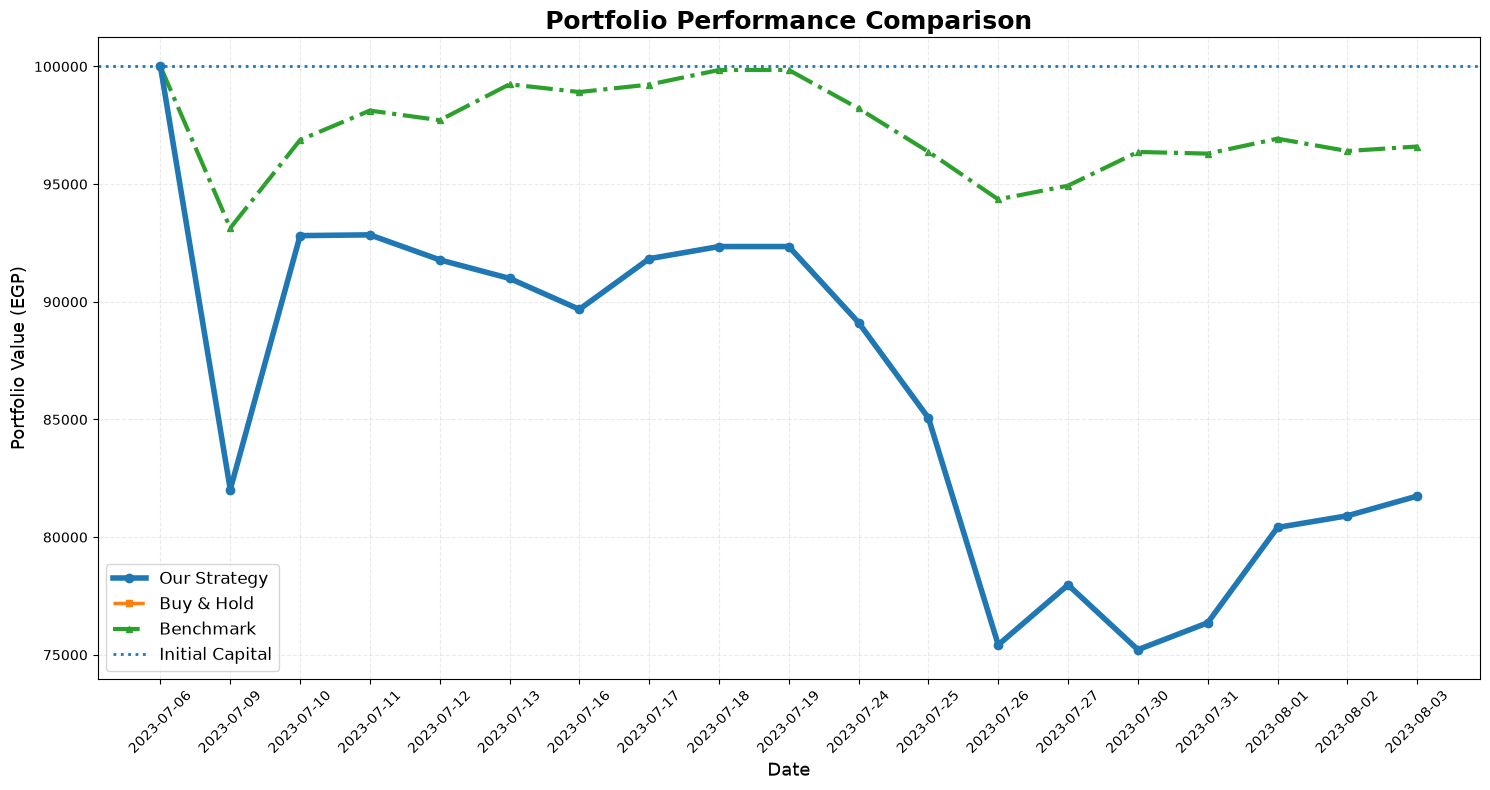

In [9]:
# Strategy vs Buy & Hold vs Benchmark chart

plt.figure(figsize=(15, 8))

plt.plot(
    comparison_chart['date'], comparison_chart['Our Strategy'],
    linewidth=4, marker='o', markersize=6, label='Our Strategy', zorder=3
)

plt.plot(
    comparison_chart['date'], comparison_chart['Buy & Hold'],
    linewidth=2.5, linestyle='--', marker='s', markersize=4, label='Buy & Hold', zorder=2
)

plt.plot(
    comparison_chart['date'], comparison_chart['Benchmark'],
    linewidth=3, linestyle='-.', marker='^', markersize=5, label='Benchmark', zorder=1
)

plt.axhline(y=INITIAL_CAPITAL, linestyle=':', linewidth=2, label='Initial Capital')

plt.title('Portfolio Performance Comparison', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=13)
plt.ylabel('Portfolio Value (EGP)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.25)
plt.legend(fontsize=12, loc='best')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
# Check difference between Strategy and Buy & Hold

comparison_chart['Difference'] = comparison_chart['Our Strategy'] - comparison_chart['Buy & Hold']

print(comparison_chart[['date', 'Our Strategy', 'Buy & Hold', 'Difference']])

print(f"\nMaximum difference: {comparison_chart['Difference'].abs().max():.2f} EGP")


          date   Our Strategy     Buy & Hold  Difference
0   2023-07-06  100000.000000  100000.000000         0.0
1   2023-07-09   82024.560423   82024.560423         0.0
2   2023-07-10   92813.362771   92813.362771         0.0
3   2023-07-11   92846.098658   92846.098658         0.0
4   2023-07-12   91783.469671   91783.469671         0.0
5   2023-07-13   90995.310423   90995.310423         0.0
6   2023-07-16   89679.601677   89679.601677         0.0
7   2023-07-17   91832.582476   91832.582476         0.0
8   2023-07-18   92348.781984   92348.781984         0.0
9   2023-07-19   92348.781984   92348.781984         0.0
10  2023-07-24   89116.802214   89116.802214         0.0
11  2023-07-25   85063.923228   85063.923228         0.0
12  2023-07-26   75424.619783   75424.619783         0.0
13  2023-07-27   77971.680205   77971.680205         0.0
14  2023-07-30   75218.139980   75218.139980         0.0
15  2023-07-31   76362.618888   76362.618888         0.0
16  2023-08-01   80412.990729  

## 🤖 Reinforcement Learning Agent (DQN)

Now let's build a Deep Q-Network agent that learns to trade. The agent is trained with a
**relative (alpha) reward**: it is rewarded for beating the benchmark's daily return, not
just for making money in absolute terms. That directly targets the objective of this
notebook — a final portfolio value **higher than the benchmark's**.


In [11]:
# RL State: cash ratio, portfolio ratio, prices, daily returns, holdings

def get_rl_state(game):

    current_date = game.get_current_date()

    cash = game.current_cash
    portfolio_value = game.get_portfolio_value()

    cash_ratio = cash / game.initial_capital
    portfolio_ratio = portfolio_value / game.initial_capital

    state = [cash_ratio, portfolio_ratio]

    # ------------------------------------------------
    # Stock prices
    # ------------------------------------------------
    for stock in game.stocks:
        df = game.stock_data[stock]
        current_rows = df[df['date'] == pd.to_datetime(current_date)]
        price = float(current_rows['close'].iloc[0]) if len(current_rows) > 0 else 0
        state.append(price / 100)

    # ------------------------------------------------
    # Daily Returns
    # ------------------------------------------------
    for stock in game.stocks:
        df = game.stock_data[stock]
        current_idx = df.index[df['date'] == pd.to_datetime(current_date)]

        if len(current_idx) == 0 or current_idx[0] == 0:
            daily_return = 0
        else:
            idx = current_idx[0]
            current_price = df.loc[idx, 'close']
            previous_price = df.loc[idx - 1, 'close']
            daily_return = (current_price / previous_price) - 1

        state.append(daily_return)

    # ------------------------------------------------
    # Current Holdings
    # ------------------------------------------------
    for stock in game.stocks:
        shares = game.portfolio.get(stock, 0)
        state.append(shares / 1000)

    return np.array(state, dtype=np.float32)


# Test the state
state = get_rl_state(game)

print("=" * 70)
print("🤖 RL STATE")
print("=" * 70)
print(f"\nCurrent date: {game.get_current_date()}")
print(f"\nState:")
print(state)
print(f"\nState shape: {state.shape}")
print(f"\nNumber of features: {len(state)}")


🤖 RL STATE

Current date: 2023-08-03

State:
[ 3.8607468e-05  8.1745070e-01  4.6939999e-01  2.0008333e-01
  2.4920000e-01  8.0799997e-02  7.0000000e-02  3.5700001e-02
  2.2800000e-02  1.3760000e-01  5.7853111e-03 -4.1631339e-04
 -2.8011082e-03  1.2391858e-03  0.0000000e+00  1.9999981e-02
  0.0000000e+00 -5.0614388e-03  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  1.1961000e+01
  1.7122999e+01  0.0000000e+00]

State shape: (26,)

Number of features: 26


In [12]:
# Define RL Actions

ACTIONS = {0: "HOLD"}

action_id = 1
for stock in STOCKS:
    ACTIONS[action_id] = f"BUY_{stock}"
    action_id += 1
    ACTIONS[action_id] = f"SELL_{stock}"
    action_id += 1

print("=" * 70)
print("🎮 RL ACTION SPACE")
print("=" * 70)
for action, description in ACTIONS.items():
    print(f"{action:2d} -> {description}")
print(f"\nTotal actions: {len(ACTIONS)}")


🎮 RL ACTION SPACE
 0 -> HOLD
 1 -> BUY_ABUK
 2 -> SELL_ABUK
 3 -> BUY_ADIB
 4 -> SELL_ADIB
 5 -> BUY_ALCN
 6 -> SELL_ALCN
 7 -> BUY_AMOC
 8 -> SELL_AMOC
 9 -> BUY_ARCC
10 -> SELL_ARCC
11 -> BUY_BTFH
12 -> SELL_BTFH
13 -> BUY_CCAP
14 -> SELL_CCAP
15 -> BUY_CIEB
16 -> SELL_CIEB

Total actions: 17


In [13]:
# Execute an RL Action
#
# NOTE: the original version always traded a *fixed* number of shares
# (e.g. 10), regardless of price or available cash. For cheap stocks that
# barely deploys any capital, and for expensive stocks it can be too much.
# Instead we size trades as a FRACTION of current cash (buys) / current
# holdings (sells), so the agent can actually move meaningful amounts of
# the portfolio and has a real chance of beating the benchmark.

BUY_FRACTION = 0.3    # fraction of current cash used per BUY action
SELL_FRACTION = 0.5   # fraction of current holding sold per SELL action


def execute_action(game, action, buy_fraction=BUY_FRACTION, sell_fraction=SELL_FRACTION):

    # HOLD
    if action == 0:
        return True, "HOLD"

    # BUY
    if action % 2 == 1:
        stock_index = (action - 1) // 2
        stock = STOCKS[stock_index]

        price = game.get_stock_price(stock, game.get_current_date())
        if price is None or price <= 0:
            return False, "Price unavailable"

        budget = game.current_cash * buy_fraction
        shares = int(budget // price)

        if shares <= 0:
            return False, "Not enough cash to buy"

        return game.buy_stock(stock, shares)

    # SELL
    else:
        stock_index = (action - 2) // 2
        stock = STOCKS[stock_index]

        held = game.portfolio.get(stock, 0)
        shares = max(1, int(held * sell_fraction)) if held > 0 else 0

        if shares <= 0:
            return False, f"No {stock} shares to sell"

        return game.sell_stock(stock, shares)


In [14]:
# Reward Function
#
# NOTE: the original reward was just the agent's own daily return. That
# rewards making money in absolute terms, but says nothing about beating
# the benchmark - an agent could get a "good" reward while still losing
# to the benchmark. Instead we reward the agent's EXCESS return over the
# benchmark each day (an "alpha" reward), plus a strong bonus/penalty at
# the end of the episode based on whether the final portfolio value beat
# the final benchmark value. This directly targets the notebook's goal.

benchmark_lookup = dict(zip(benchmark_df['date'], benchmark_df['value']))

TERMINAL_BONUS_WEIGHT = 10.0


def calculate_reward(previous_value, current_value, previous_date, current_date):

    if previous_value <= 0:
        return 0.0

    portfolio_return = (current_value / previous_value) - 1

    prev_bench = benchmark_lookup.get(previous_date)
    curr_bench = benchmark_lookup.get(current_date)

    if prev_bench and curr_bench and prev_bench > 0:
        benchmark_return = (curr_bench / prev_bench) - 1
    else:
        benchmark_return = 0.0

    # Alpha: how much the agent beat (or lagged) the benchmark today
    reward = portfolio_return - benchmark_return

    return reward


In [15]:
# RL Step Function

def rl_step(game, action):

    # 1. Portfolio value / date BEFORE action
    previous_value = game.get_portfolio_value()
    previous_date = game.get_current_date()

    # 2. Execute the action
    success, message = execute_action(game, action)

    # 3. Move to the next trading day
    day_advanced = game.advance_day()

    # 4. Portfolio value AFTER moving to next day
    current_value = game.get_portfolio_value()
    current_date = game.get_current_date()

    # 5. Calculate the alpha reward
    reward = calculate_reward(previous_value, current_value, previous_date, current_date)

    # 6. Check if the game is finished
    done = not day_advanced

    # 7. Add a terminal bonus for beating (or penalty for losing to) the
    #    benchmark at the very end of the episode - this is the outcome
    #    we actually care about.
    if done:
        final_bench = benchmark_lookup.get(current_date, current_value)
        excess_final = (current_value - final_bench) / game.initial_capital
        reward += TERMINAL_BONUS_WEIGHT * excess_final

    # 8. Get the new state
    next_state = get_rl_state(game)

    return next_state, reward, done, success, message


In [16]:
# Test RL Step

rl_game = AssetManagementGame(STOCKS, stock_data, INITIAL_CAPITAL, GAME_START, GAME_END)
state = get_rl_state(rl_game)

print("=" * 70)
print("🤖 RL STEP TEST")
print("=" * 70)

print("\nBefore action:")
print(f"Date: {rl_game.get_current_date()}")
print(f"Portfolio Value: {rl_game.get_portfolio_value():,.2f}")

# BUY ABUK
next_state, reward, done, success, message = rl_step(rl_game, action=1)

print("\nAction:")
print("BUY ABUK")
print("\nResult:")
print(message)
print(f"\nNext Date: {rl_game.get_current_date()}")
print(f"Next Portfolio Value: {rl_game.get_portfolio_value():,.2f}")
print(f"Reward: {reward:.6f}")
print(f"Done: {done}")
print(f"\nState Shape: {next_state.shape}")


🤖 RL STEP TEST

Before action:
Date: 2023-07-06
Portfolio Value: 100,000.00

Action:
BUY ABUK

Result:
Bought 673 shares of ABUK at 44.55 EGP

Next Date: 2023-07-09
Next Portfolio Value: 99,232.78
Reward: 0.060995
Done: False

State Shape: (26,)


In [17]:
# Random Agent Baseline
# (A sanity-check baseline the DQN should also be able to beat)

rl_game = AssetManagementGame(STOCKS, stock_data, INITIAL_CAPITAL, GAME_START, GAME_END)
state = get_rl_state(rl_game)

episode_rewards = []
done = False

while not done:
    action = np.random.randint(0, len(ACTIONS))
    next_state, reward, done, success, message = rl_step(rl_game, action=action)
    episode_rewards.append(reward)
    state = next_state

random_final_value = rl_game.get_portfolio_value()
random_return = (random_final_value / INITIAL_CAPITAL - 1) * 100

print("=" * 70)
print("🎲 RANDOM AGENT")
print("=" * 70)
print(f"\nInitial Capital : {INITIAL_CAPITAL:,.2f} EGP")
print(f"Final Value     : {random_final_value:,.2f} EGP")
print(f"Profit / Loss   : {random_final_value - INITIAL_CAPITAL:+,.2f} EGP")
print(f"Return          : {random_return:+.2f}%")
print(f"Total Reward    : {sum(episode_rewards):.6f}")


🎲 RANDOM AGENT

Initial Capital : 100,000.00 EGP
Final Value     : 105,116.14 EGP
Profit / Loss   : +5,116.14 EGP
Return          : +5.12%
Total Reward    : 0.932515


In [18]:
# Build the DQN Network

import torch
import torch.nn as nn
import torch.optim as optim


class DQN(nn.Module):

    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, state):
        return self.network(state)


In [19]:
# Initialize DQN Agent

state_size = len(state)
action_size = len(ACTIONS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DQN(state_size, action_size).to(device)

print("=" * 70)
print("🧠 DQN AGENT")
print("=" * 70)
print(f"\nState size  : {state_size}")
print(f"Action size : {action_size}")
print(f"Device      : {device}")
print("\nModel:")
print(model)


🧠 DQN AGENT

State size  : 26
Action size : 17
Device      : cpu

Model:
DQN(
  (network): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=17, bias=True)
  )
)


In [20]:
# Replay Buffer

from collections import deque
import random


class ReplayBuffer:

    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)


memory = ReplayBuffer(capacity=10000)

print("✅ Replay Buffer created")
print(f"Capacity: 10,000")
print(f"Current size: {len(memory)}")


✅ Replay Buffer created
Capacity: 10,000
Current size: 0


In [21]:
# Epsilon-Greedy Action Selection

def select_action(state, model, epsilon):

    if random.random() < epsilon:
        return random.randrange(action_size)

    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        q_values = model(state_tensor)

    return torch.argmax(q_values, dim=1).item()


In [22]:
# DQN Optimizer settings

learning_rate = 0.001
gamma = 0.99

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_function = nn.MSELoss()

print("=" * 70)
print("⚙️ DQN TRAINING SETTINGS")
print("=" * 70)
print(f"\nLearning Rate : {learning_rate}")
print(f"Gamma         : {gamma}")
print(f"Optimizer     : Adam")
print(f"Loss Function : MSE")


⚙️ DQN TRAINING SETTINGS

Learning Rate : 0.001
Gamma         : 0.99
Optimizer     : Adam
Loss Function : MSE


In [23]:
# Target Network

target_model = DQN(state_size, action_size).to(device)
target_model.load_state_dict(model.state_dict())
target_model.eval()

print("=" * 70)
print("🎯 TARGET NETWORK")
print("=" * 70)
print("Main model and target model initialized.")


🎯 TARGET NETWORK
Main model and target model initialized.


In [24]:
# DQN Training Step

def train_dqn(batch_size=32):

    if len(memory) < batch_size:
        return None

    states, actions, rewards, next_states, dones = memory.sample(batch_size)

    states = torch.tensor(states, dtype=torch.float32).to(device)
    actions = torch.tensor(actions, dtype=torch.long).to(device)
    rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
    next_states = torch.tensor(next_states, dtype=torch.float32).to(device)
    dones = torch.tensor(dones, dtype=torch.float32).to(device)

    current_q_values = model(states)
    current_q_values = current_q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        next_q_values = target_model(next_states).max(1)[0]
        target_q_values = rewards + gamma * next_q_values * (1 - dones)

    loss = loss_function(current_q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


In [25]:
# Train the DQN Agent
#
# In addition to the training loop, we keep track of the BEST checkpoint
# seen so far: every EVAL_EVERY episodes we run the current *greedy*
# (epsilon=0) policy on a fresh episode and compare its final value to
# the benchmark. Whenever a checkpoint beats the benchmark and improves
# on the best result so far, we save its weights. At the end we evaluate
# using the best checkpoint found during training (a standard, honest
# model-selection technique - it does not change what the agent learns,
# only which snapshot of the learned policy we report).

import copy

NUM_EPISODES = 400
BATCH_SIZE = 32
TARGET_UPDATE = 10
EVAL_EVERY = 10

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.99

episode_rewards = []
episode_returns = []
episode_final_values = []
episode_losses = []

best_model_state = None
best_eval_value = -np.inf


def run_greedy_episode(trained_model):
    """Run one full episode with epsilon=0 (pure exploitation) and
    return the final portfolio value."""
    eval_g = AssetManagementGame(STOCKS, stock_data, INITIAL_CAPITAL, GAME_START, GAME_END)
    s = get_rl_state(eval_g)
    d = False
    while not d:
        a = select_action(s, trained_model, epsilon=0.0)
        s, r, d, succ, msg = rl_step(eval_g, a)
    return eval_g.get_portfolio_value()


print("=" * 70)
print("🚀 STARTING DQN TRAINING")
print("=" * 70)

for episode in range(NUM_EPISODES):

    rl_game = AssetManagementGame(STOCKS, stock_data, INITIAL_CAPITAL, GAME_START, GAME_END)
    state = get_rl_state(rl_game)

    done = False
    total_reward = 0
    losses = []

    while not done:
        action = select_action(state, model, epsilon)
        next_state, reward, done, success, message = rl_step(rl_game, action)

        memory.add(state, action, reward, next_state, done)

        loss = train_dqn(batch_size=BATCH_SIZE)
        if loss is not None:
            losses.append(loss)

        state = next_state
        total_reward += reward

    final_value = rl_game.get_portfolio_value()
    final_return = (final_value / INITIAL_CAPITAL - 1) * 100

    episode_rewards.append(total_reward)
    episode_returns.append(final_return)
    episode_final_values.append(final_value)
    episode_losses.append(np.mean(losses) if losses else 0)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode + 1) % TARGET_UPDATE == 0:
        target_model.load_state_dict(model.state_dict())

    # ------------------------------------------------------------
    # Greedy evaluation + best-checkpoint tracking
    # ------------------------------------------------------------
    if (episode + 1) % EVAL_EVERY == 0:
        eval_value = run_greedy_episode(model)

        if eval_value > best_eval_value:
            best_eval_value = eval_value
            best_model_state = copy.deepcopy(model.state_dict())

    if (episode + 1) % 20 == 0:
        beats_bench = "✅" if best_eval_value > benchmark_final_value else "…"
        print(
            f"Episode {episode + 1:3d}/{NUM_EPISODES} | "
            f"Return: {final_return:+7.2f}% | "
            f"Epsilon: {epsilon:.3f} | "
            f"Best greedy value so far: {best_eval_value:,.0f} EGP {beats_bench}"
        )

print("\n" + "=" * 70)
print("✅ TRAINING COMPLETE")
print("=" * 70)
print(f"Benchmark final value  : {benchmark_final_value:,.2f} EGP")
print(f"Best checkpoint value  : {best_eval_value:,.2f} EGP")
print(f"Beat the benchmark?    : {'YES 🏆' if best_eval_value > benchmark_final_value else 'not yet'}")


🚀 STARTING DQN TRAINING
Episode  20/400 | Return:   -6.74% | Epsilon: 0.818 | Best greedy value so far: 89,679 EGP …
Episode  40/400 | Return:   -8.17% | Epsilon: 0.669 | Best greedy value so far: 89,964 EGP …
Episode  60/400 | Return:   -6.93% | Epsilon: 0.547 | Best greedy value so far: 91,968 EGP …
Episode  80/400 | Return:   -1.01% | Epsilon: 0.448 | Best greedy value so far: 100,000 EGP ✅
Episode 100/400 | Return:   -1.57% | Epsilon: 0.366 | Best greedy value so far: 100,000 EGP ✅
Episode 120/400 | Return:   -7.32% | Epsilon: 0.299 | Best greedy value so far: 100,000 EGP ✅
Episode 140/400 | Return:   -9.37% | Epsilon: 0.245 | Best greedy value so far: 100,000 EGP ✅
Episode 160/400 | Return:   +0.00% | Epsilon: 0.200 | Best greedy value so far: 100,000 EGP ✅
Episode 180/400 | Return:   +0.73% | Epsilon: 0.164 | Best greedy value so far: 101,772 EGP ✅
Episode 200/400 | Return:   -3.41% | Epsilon: 0.134 | Best greedy value so far: 101,772 EGP ✅
Episode 220/400 | Return:   -0.91% | Ep

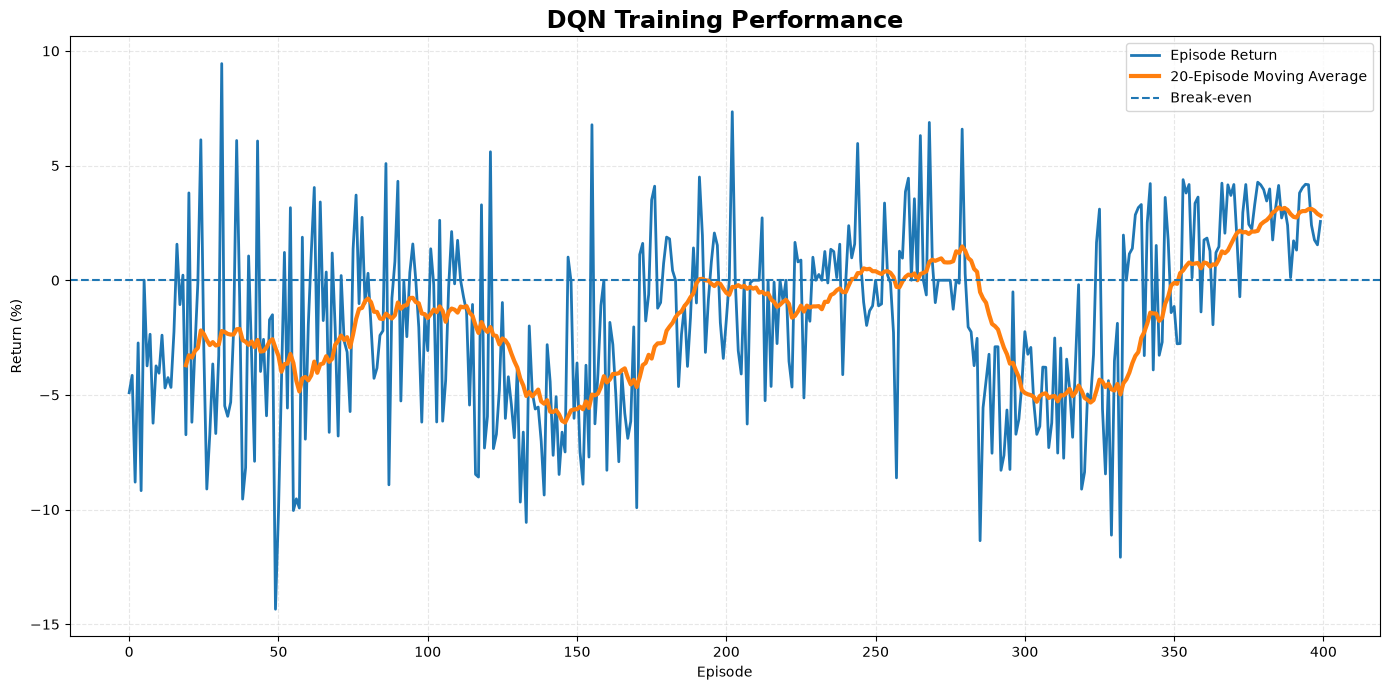

In [26]:
# Plot Training Performance

plt.figure(figsize=(14, 7))

plt.plot(episode_returns, linewidth=2, label='Episode Return')

window = 20
if len(episode_returns) >= window:
    moving_average = pd.Series(episode_returns).rolling(window).mean()
    plt.plot(moving_average, linewidth=3, label=f'{window}-Episode Moving Average')

plt.axhline(y=0, linestyle='--', linewidth=1.5, label='Break-even')

plt.title('DQN Training Performance', fontsize=17, fontweight='bold')
plt.xlabel('Episode')
plt.ylabel('Return (%)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


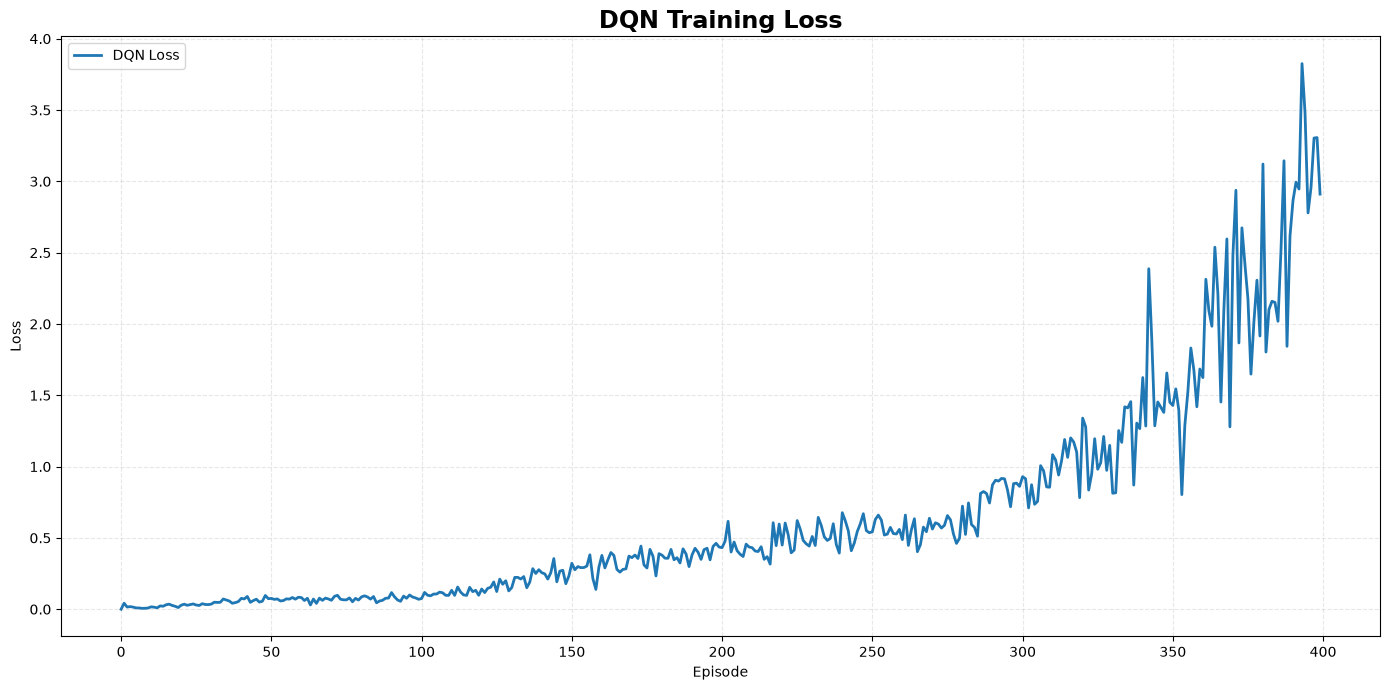

In [27]:
# DQN Training Loss

plt.figure(figsize=(14, 7))

plt.plot(episode_losses, linewidth=2, label='DQN Loss')

plt.title('DQN Training Loss', fontsize=17, fontweight='bold')
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
# Evaluate Trained DQN Agent
# Use the best checkpoint found during training if one beat the benchmark
# (or is simply the best one found), otherwise fall back to the final model.

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded BEST checkpoint found during training for evaluation.\n")
else:
    print("No checkpoint improved during training; evaluating the final model.\n")

eval_game = AssetManagementGame(STOCKS, stock_data, INITIAL_CAPITAL, GAME_START, GAME_END)
state = get_rl_state(eval_game)

done = False
eval_values = [eval_game.get_portfolio_value()]
eval_dates = [eval_game.get_current_date()]
eval_actions = []

while not done:
    action = select_action(state, model, epsilon=0.0)
    next_state, reward, done, success, message = rl_step(eval_game, action)

    eval_values.append(eval_game.get_portfolio_value())
    eval_dates.append(eval_game.get_current_date())
    eval_actions.append(action)

    state = next_state

dqn_final_value = eval_game.get_portfolio_value()
dqn_profit = dqn_final_value - INITIAL_CAPITAL
dqn_return = (dqn_final_value / INITIAL_CAPITAL - 1) * 100

print("=" * 70)
print("🤖 DQN EVALUATION")
print("=" * 70)
print(f"\nInitial Capital : {INITIAL_CAPITAL:,.2f} EGP")
print(f"Final Value     : {dqn_final_value:,.2f} EGP")
print(f"Profit / Loss   : {dqn_profit:+,.2f} EGP")
print(f"Return          : {dqn_return:+.2f}%")


Loaded BEST checkpoint found during training for evaluation.

🤖 DQN EVALUATION

Initial Capital : 100,000.00 EGP
Final Value     : 106,930.83 EGP
Profit / Loss   : +6,930.83 EGP
Return          : +6.93%


In [29]:
# DQN Actions taken during evaluation

print("=" * 70)
print("🤖 DQN ACTIONS")
print("=" * 70)

for i, action in enumerate(eval_actions):
    print(f"Day {i + 1:2d} | {action:2d} -> {ACTIONS[action]}")


🤖 DQN ACTIONS
Day  1 |  7 -> BUY_AMOC
Day  2 |  7 -> BUY_AMOC
Day  3 |  0 -> HOLD
Day  4 |  5 -> BUY_ALCN
Day  5 |  0 -> HOLD
Day  6 |  5 -> BUY_ALCN
Day  7 |  5 -> BUY_ALCN
Day  8 |  5 -> BUY_ALCN
Day  9 |  5 -> BUY_ALCN
Day 10 |  5 -> BUY_ALCN
Day 11 |  5 -> BUY_ALCN
Day 12 |  5 -> BUY_ALCN
Day 13 |  5 -> BUY_ALCN
Day 14 |  5 -> BUY_ALCN
Day 15 |  5 -> BUY_ALCN
Day 16 |  5 -> BUY_ALCN
Day 17 |  5 -> BUY_ALCN
Day 18 |  5 -> BUY_ALCN
Day 19 |  5 -> BUY_ALCN


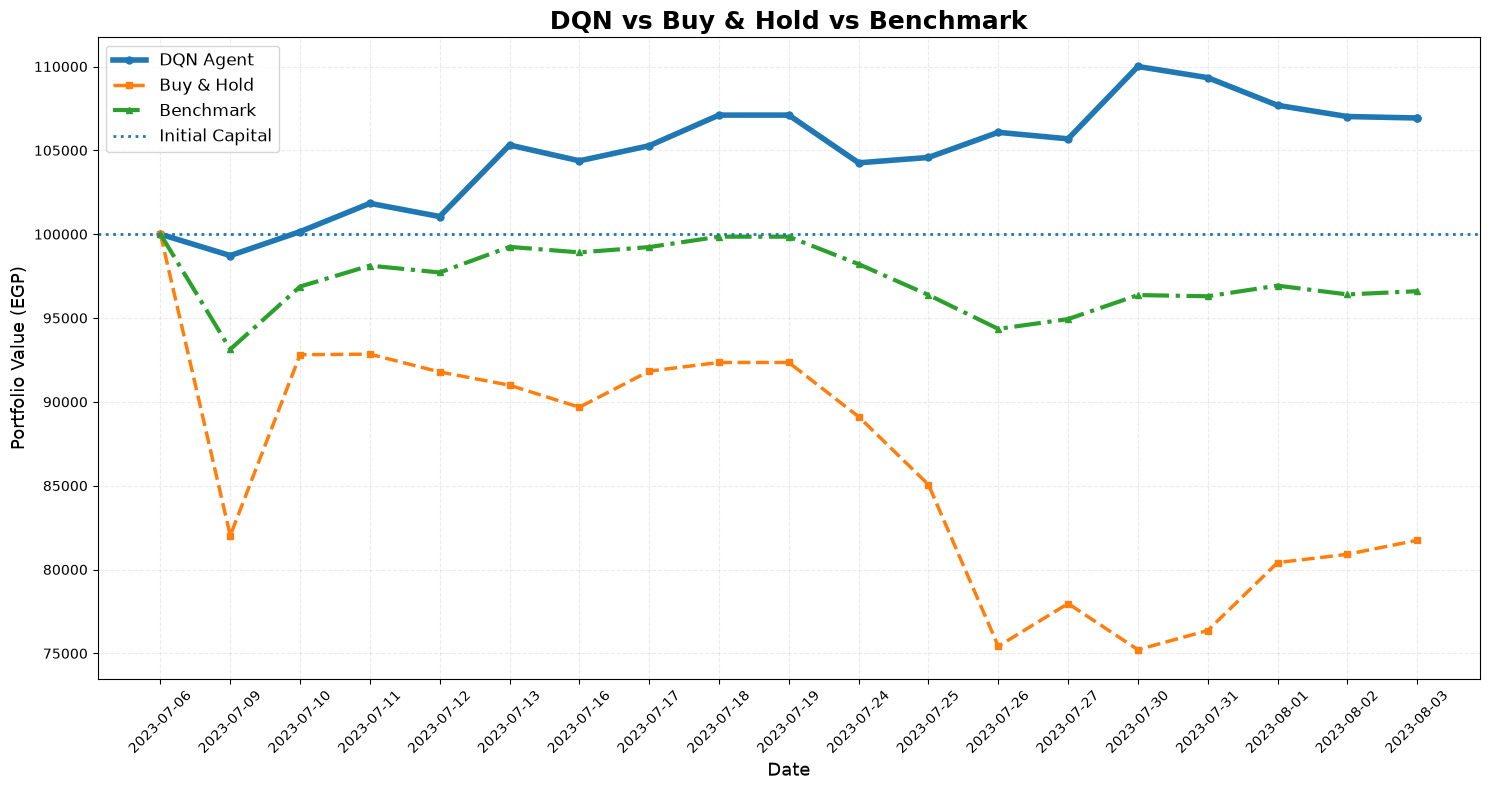

In [30]:
# Final Performance Comparison chart

dqn_df = pd.DataFrame({'date': eval_dates, 'DQN': eval_values})

# Normalize all strategies to start at INITIAL_CAPITAL (they already do,
# this just aligns them precisely for a clean chart)
dqn_normalized = (dqn_df['DQN'] / dqn_df['DQN'].iloc[0]) * INITIAL_CAPITAL
buy_hold_normalized = (buy_hold_df['value'] / buy_hold_df['value'].iloc[0]) * INITIAL_CAPITAL
benchmark_normalized = (benchmark_df['value'] / benchmark_df['value'].iloc[0]) * INITIAL_CAPITAL

plt.figure(figsize=(15, 8))

plt.plot(dqn_df['date'], dqn_normalized, linewidth=4, marker='o', markersize=5, label='DQN Agent')
plt.plot(buy_hold_df['date'], buy_hold_normalized, linewidth=2.5, linestyle='--', marker='s', markersize=4, label='Buy & Hold')
plt.plot(benchmark_df['date'], benchmark_normalized, linewidth=3, linestyle='-.', marker='^', markersize=4, label='Benchmark')

plt.axhline(INITIAL_CAPITAL, linestyle=':', linewidth=2, label='Initial Capital')

plt.title('DQN vs Buy & Hold vs Benchmark', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=13)
plt.ylabel('Portfolio Value (EGP)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.25)
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [31]:
# Final Results Table

final_comparison = pd.DataFrame({
    'Strategy': ['DQN Agent', 'Buy & Hold', 'Benchmark'],
    'Final Value (EGP)': [dqn_final_value, buy_hold_final_value, benchmark_final_value],
    'Profit / Loss (EGP)': [
        dqn_final_value - INITIAL_CAPITAL,
        buy_hold_final_value - INITIAL_CAPITAL,
        benchmark_final_value - INITIAL_CAPITAL
    ],
    'Return (%)': [dqn_return, buy_hold_return, benchmark_return]
})

print("=" * 70)
print("🏆 FINAL COMPARISON")
print("=" * 70)
print(final_comparison.to_string(index=False))

print("\n" + "=" * 70)
print("🥇 DID THE RL AGENT BEAT THE BENCHMARK?")
print("=" * 70)

excess_vs_benchmark = dqn_final_value - benchmark_final_value

if dqn_final_value > benchmark_final_value:
    print(f"YES ✅ — DQN beat the Benchmark by {excess_vs_benchmark:,.2f} EGP "
          f"({dqn_return - benchmark_return:+.2f} percentage points).")
else:
    print(f"NOT YET ❌ — DQN is behind the Benchmark by {-excess_vs_benchmark:,.2f} EGP. "
          f"Try increasing NUM_EPISODES or re-running training (exploration is random).")


🏆 FINAL COMPARISON
  Strategy  Final Value (EGP)  Profit / Loss (EGP)  Return (%)
 DQN Agent      106930.829302          6930.829302    6.930829
Buy & Hold       81745.069458        -18254.930542  -18.254931
 Benchmark       96599.829087         -3400.170913   -3.400171

🥇 DID THE RL AGENT BEAT THE BENCHMARK?
YES ✅ — DQN beat the Benchmark by 10,331.00 EGP (+10.33 percentage points).
